# Fund Analysis and Visualization Examples

This notebook demonstrates how to use the visualization functions in the Scrappy class to analyze fund relationships, performance metrics, and benchmark comparisons.

In [4]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the src directory to the path so we can import the Scrappy class
from src.scrappy import Scrappy

## Initialize the Scrappy Class

First, let's initialize the Scrappy class with our data files.

In [5]:
# Initialize Scrappy with data files
s = Scrappy(
    funds_overview_path='data/funds_overview.csv',
    performance_path='data/performance.csv',
    timeseries_path='data/timeseries.csv'
)

## 1. Correlation Analysis

Let's select a set of funds to analyze their correlations. We'll focus on sustainable funds with a savings plan option.

In [6]:
sustainable_sparplan_funds = s.funds_overview[s.funds_overview['sparplan_finanzen_zero'] == True]

print(f"Found {len(sustainable_sparplan_funds)} sustainable funds with savings plan option")

# Take a sample of 10 funds for visualization
sample_funds = list(sustainable_sparplan_funds[:10])

# Add benchmark ETFs
benchmark_isins = [
    'IE00B5BMR087',  # iShares Core S&P 500 UCITS ETF
    'DE000A0F5UF5',  # iShares STOXX Europe 600 UCITS ETF
    'IE0005042456',  # iShares MSCI EM UCITS ETF
    'DE0006289390',  # iShares MSCI Japan UCITS ETF
    'DE0005933931',  # iShares Core DAX UCITS ETF
    'LU0340285161'   # Xtrackers MSCI World UCITS ETF
]

# Ensure we have time series data for these funds
all_isins = sample_funds + benchmark_isins
s.get_timeseries(all_isins)

# Show the funds we'll analyze
s.select_funds(all_isins)[['name', 'TER']]

                                                           name  type  \
isin                                                                    
LU1978536115           DWS Invest ESG Qi US Equity - RC USD ACC  FUND   
LU2146568766                Amundi Fds.Pio.US Eq.ESG Imp.M2 EUR  FUND   
LU0377750707                     GS Gl.Eq.Partners ESG Pf.A USD  FUND   
LU0377750533                     GS Gl.Eq.Partners ESG Pf.A USD  FUND   
LU0377751341                     GS Gl.Eq.Partners ESG Pf.E EUR  FUND   
...                                                         ...   ...   
LU2504537445  Xtrackers II Eurozone Government Bond ESG Tilt...   ETF   
LU2194286006  UBS ETF JP Morgan EMU Government ESG Liquid Bo...   ETF   
LU2468423459  Xtrackers II ESG Eurozone Government Bond UCIT...   ETF   
LU2742533636  BNP Paribas Easy JPM ESG EMU Government Bond I...   ETF   
LU2742533552  BNP Paribas Easy JPM ESG EMU Government Bond I...   ETF   

                            investment_focus      

,name,TER
isin,,
DE0005933931,iShares Core DAX UCITS ETF EUR Acc. (DE),0.16
DE000A0F5UF5,iShares NASDAQ-100 UCITS ETF USD Dis. (DE),0.31
IE00B5BMR087,iShares Core S&P 500 UCITS ETF USD Acc.,0.07
LU0340285161,UBS ETF MSCI World UCITS ETF A USD Dis.,0.31
IE0005042456,iShares Core FTSE 100 UCITS ETF GBP Dis.,0.10
DE0006289390,iShares DJ Industrial Average UCITS ETF USD Di...,0.51


In [7]:
s.save_timeseries()

### 1.1 Create Correlation Heatmap

Now, let's visualize the correlations between these funds.

Not in ts: ['name', 'type', 'investment_focus', 'region', 'issuer', 'benchmark', 'country', 'currency', 'volume', 'fund_type', 'initial_fee', 'TER', 'morningstar', 'morningstar_3y', 'morningstar_5y', 'feri', 'risk_class', 'performance', 'risk', 'wkn', 'all_in_fee', 'currency_fee', 'depot_bank_fee', 'switching_fee', 'distribution_fee', 'redemption_fee', 'min_initial_investment', 'min_followup_investment', 'sparplan_finanzen_zero', 'finanzen_zero']


/home/igor/git/scrappy/src/scrappy.py:665: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = ts_data.pct_change().dropna()


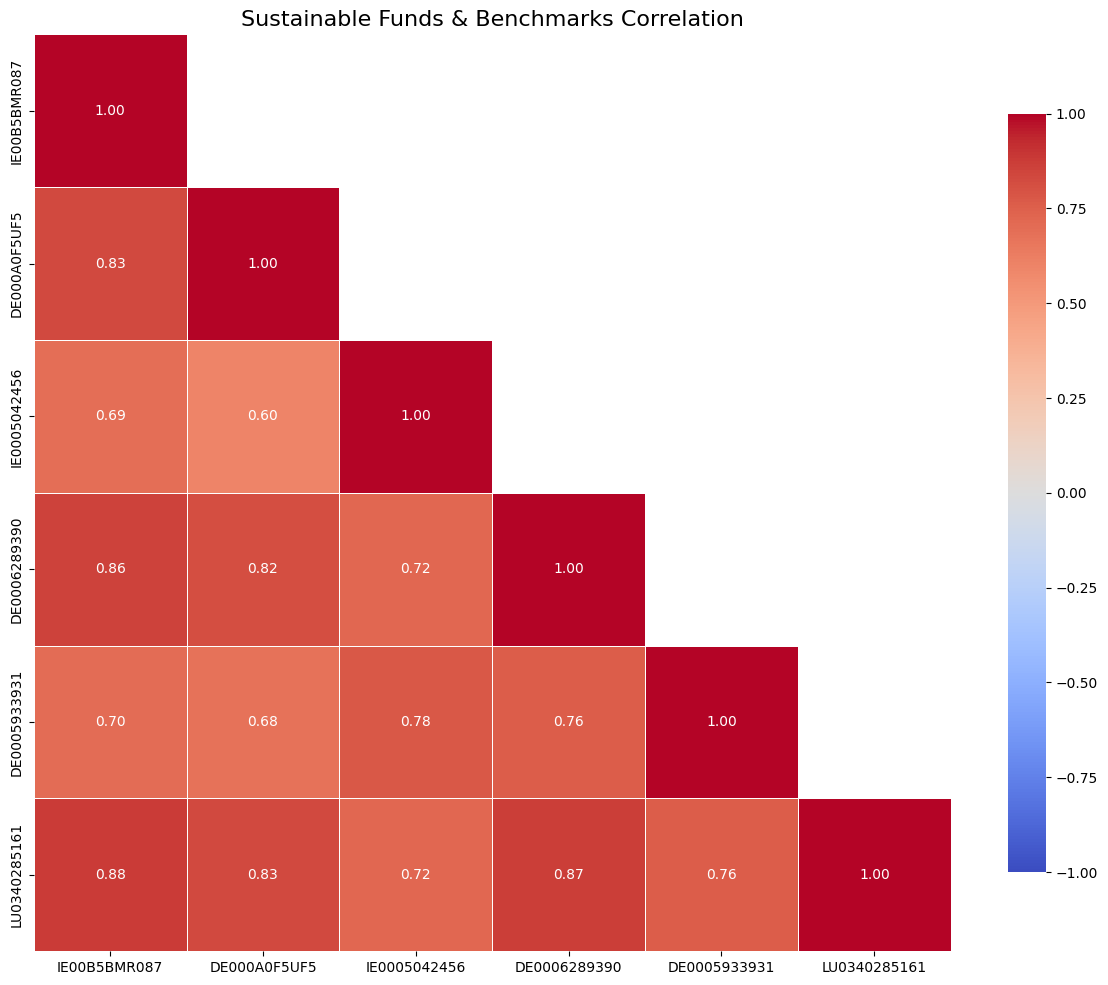

In [9]:
# Plot correlation heatmap of all the funds
corr_matrix = s.plot_fund_correlations(isins=all_isins, title='Sustainable Funds & Benchmarks Correlation')

# You can also look at just the sustainable funds, without benchmarks
# s.plot_fund_correlations(isins=sample_funds, title='Sustainable Funds Correlation')

## 2. Risk-Return Analysis

Let's create a risk-return scatter plot to visualize the performance of funds relative to their risk.

In [10]:
# Create a risk-return scatter plot for 1-year timeframe
risk_return_1y = s.plot_risk_return(
    timespan='1Y',
    isins=sample_funds,
    benchmark_isins=benchmark_isins,
    include_labels=True
)

# Look at the 3-year risk-return profile for comparison
risk_return_3y = s.plot_risk_return(
    timespan='3Y',
    isins=sample_funds,
    benchmark_isins=benchmark_isins,
    include_labels=True
)

Not found: ['investment_focus', 'currency_fee', 'all_in_fee', 'type', 'switching_fee', 'fund_type', 'performance', 'morningstar_3y', 'benchmark', 'min_followup_investment', 'issuer', 'TER', 'initial_fee', 'region', 'morningstar_5y', 'wkn', 'distribution_fee', 'redemption_fee', 'risk', 'volume', 'name', 'morningstar', 'feri', 'depot_bank_fee', 'country', 'risk_class', 'finanzen_zero', 'min_initial_investment', 'sparplan_finanzen_zero', 'currency']
No fund data available for analysis.
Not found: ['investment_focus', 'currency_fee', 'all_in_fee', 'type', 'switching_fee', 'fund_type', 'performance', 'morningstar_3y', 'benchmark', 'min_followup_investment', 'issuer', 'TER', 'initial_fee', 'region', 'morningstar_5y', 'wkn', 'distribution_fee', 'redemption_fee', 'risk', 'volume', 'name', 'morningstar', 'feri', 'depot_bank_fee', 'country', 'risk_class', 'finanzen_zero', 'min_initial_investment', 'sparplan_finanzen_zero', 'currency']
No fund data available for analysis.


Let's create a table comparing the risk-return profiles of these funds across different time periods.

Not found: ['investment_focus', 'currency_fee', 'all_in_fee', 'type', 'switching_fee', 'fund_type', 'performance', 'morningstar_3y', 'benchmark', 'min_followup_investment', 'issuer', 'TER', 'initial_fee', 'region', 'morningstar_5y', 'wkn', 'distribution_fee', 'redemption_fee', 'risk', 'volume', 'name', 'morningstar', 'feri', 'depot_bank_fee', 'country', 'risk_class', 'finanzen_zero', 'min_initial_investment', 'sparplan_finanzen_zero', 'currency']


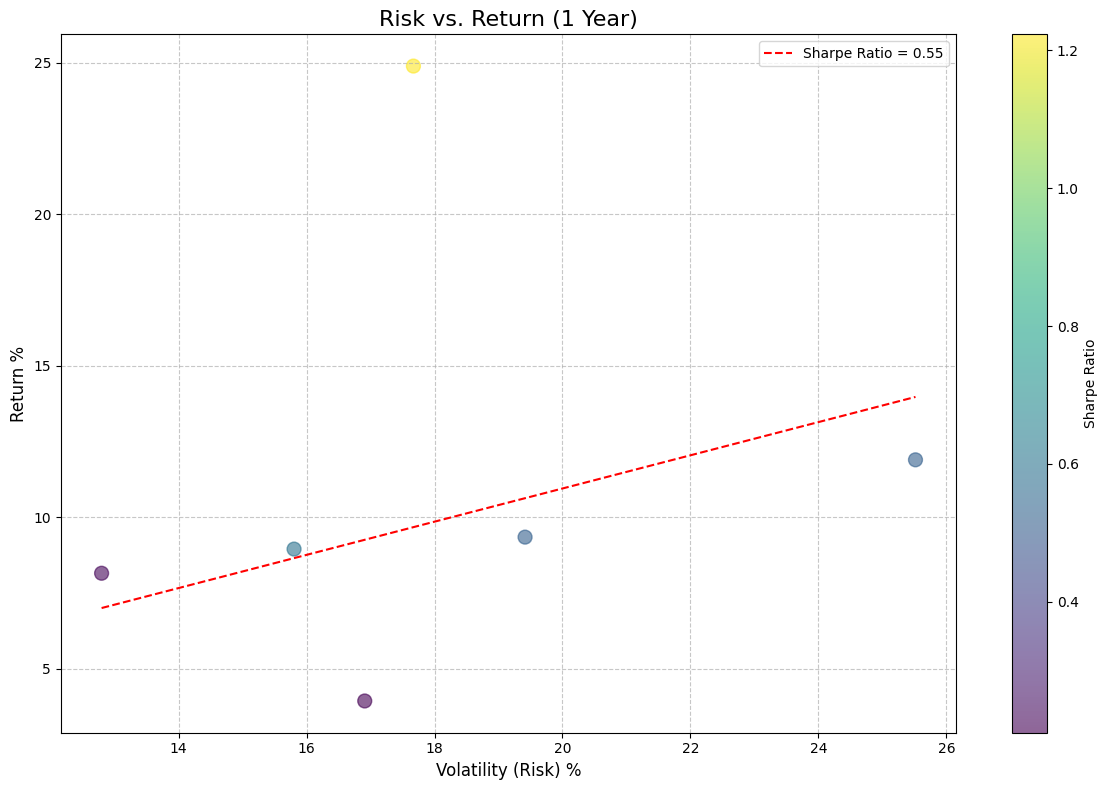


1Y Performance Summary:


,Return (%),Volatility (%),Sharpe Ratio
DE0005933931,24.8931,17.6705,1.2231
LU0340285161,8.9535,15.8049,0.5939
IE00B5BMR087,9.3480,19.4156,0.5182
DE000A0F5UF5,11.8992,25.5179,0.5165
IE0005042456,8.1560,12.7966,0.2240
DE0006289390,3.9408,16.9096,0.2102


Not found: ['investment_focus', 'currency_fee', 'all_in_fee', 'type', 'switching_fee', 'fund_type', 'performance', 'morningstar_3y', 'benchmark', 'min_followup_investment', 'issuer', 'TER', 'initial_fee', 'region', 'morningstar_5y', 'wkn', 'distribution_fee', 'redemption_fee', 'risk', 'volume', 'name', 'morningstar', 'feri', 'depot_bank_fee', 'country', 'risk_class', 'finanzen_zero', 'min_initial_investment', 'sparplan_finanzen_zero', 'currency']


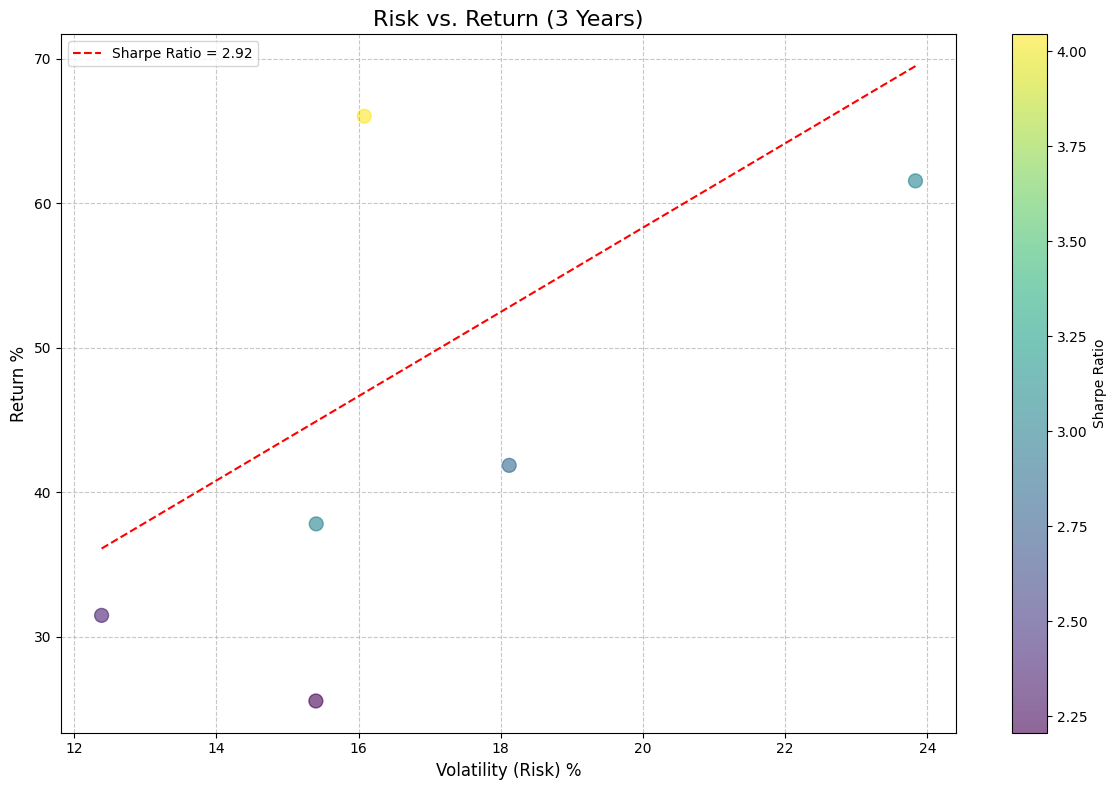


3Y Performance Summary:


,Return (%),Volatility (%),Sharpe Ratio
DE0005933931,66.0243,16.0792,4.0440
DE000A0F5UF5,61.5535,23.8335,3.0418
LU0340285161,37.8189,15.4039,3.0283
IE00B5BMR087,41.8678,18.1184,2.8161
IE0005042456,31.4885,12.3849,2.3586
DE0006289390,25.5656,15.3989,2.2060


Not found: ['investment_focus', 'currency_fee', 'all_in_fee', 'type', 'switching_fee', 'fund_type', 'performance', 'morningstar_3y', 'benchmark', 'min_followup_investment', 'issuer', 'TER', 'initial_fee', 'region', 'morningstar_5y', 'wkn', 'distribution_fee', 'redemption_fee', 'risk', 'volume', 'name', 'morningstar', 'feri', 'depot_bank_fee', 'country', 'risk_class', 'finanzen_zero', 'min_initial_investment', 'sparplan_finanzen_zero', 'currency']


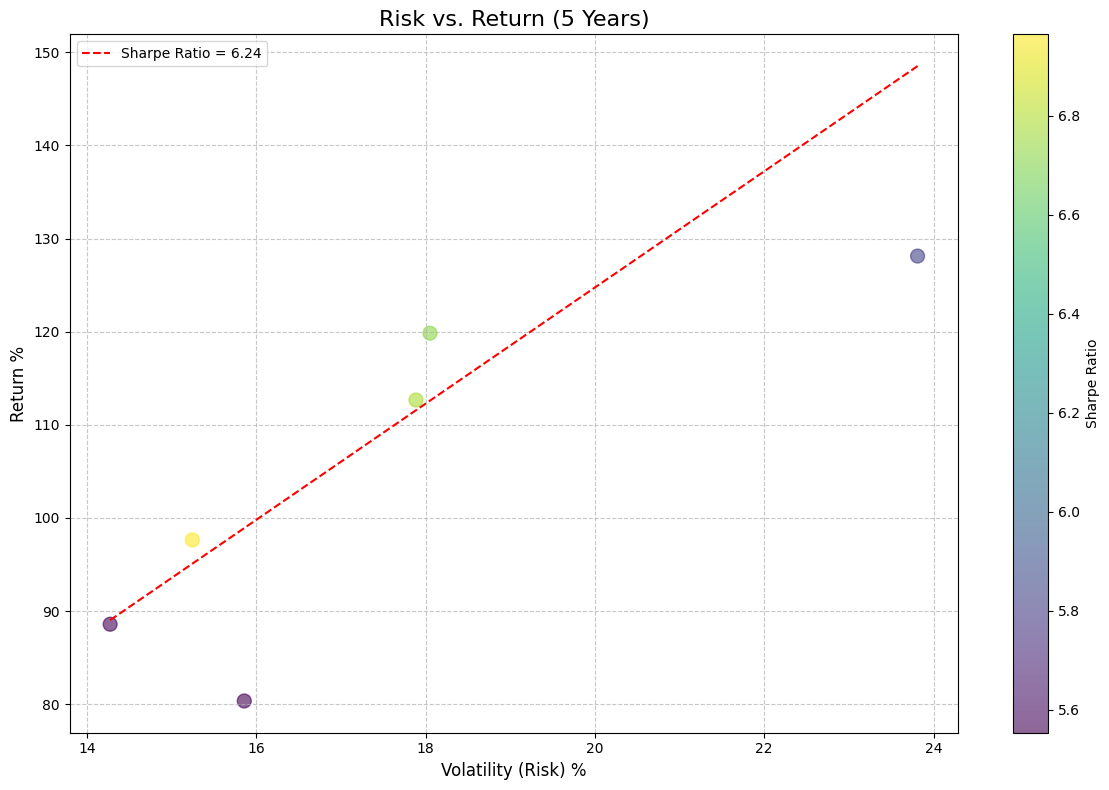


5Y Performance Summary:


,Return (%),Volatility (%),Sharpe Ratio
LU0340285161,97.6388,15.2461,6.9642
IE00B5BMR087,112.6600,17.8870,6.7831
DE0005933931,119.8370,18.0523,6.7214
DE000A0F5UF5,128.1150,23.8114,5.8292
IE0005042456,88.5903,14.2751,5.5702
DE0006289390,80.3504,15.8592,5.5537


In [13]:
# Get performance for all time periods
for period in ['1Y', '3Y', '5Y']:
    risk_return = s.plot_risk_return(
        timespan=period,
        isins=sample_funds + benchmark_isins,
        include_labels=False  # No labels for cleaner visualization
    )
    
    if risk_return is not None:
        print(f"\n{period} Performance Summary:")
        summary = risk_return.sort_values('sharpe', ascending=False)[['return', 'volatility', 'sharpe']]
        summary.columns = ['Return (%)', 'Volatility (%)', 'Sharpe Ratio']
        display(summary.head(10))  # Show top 10 by Sharpe ratio

## 3. Benchmark Comparison

Now let's compare our sample funds against market benchmarks by normalizing their performance to a specific date.

Not in ts: ['issuer', 'investment_focus', 'type', 'name', 'region']


AttributeError: 'str' object has no attribute 'strftime'

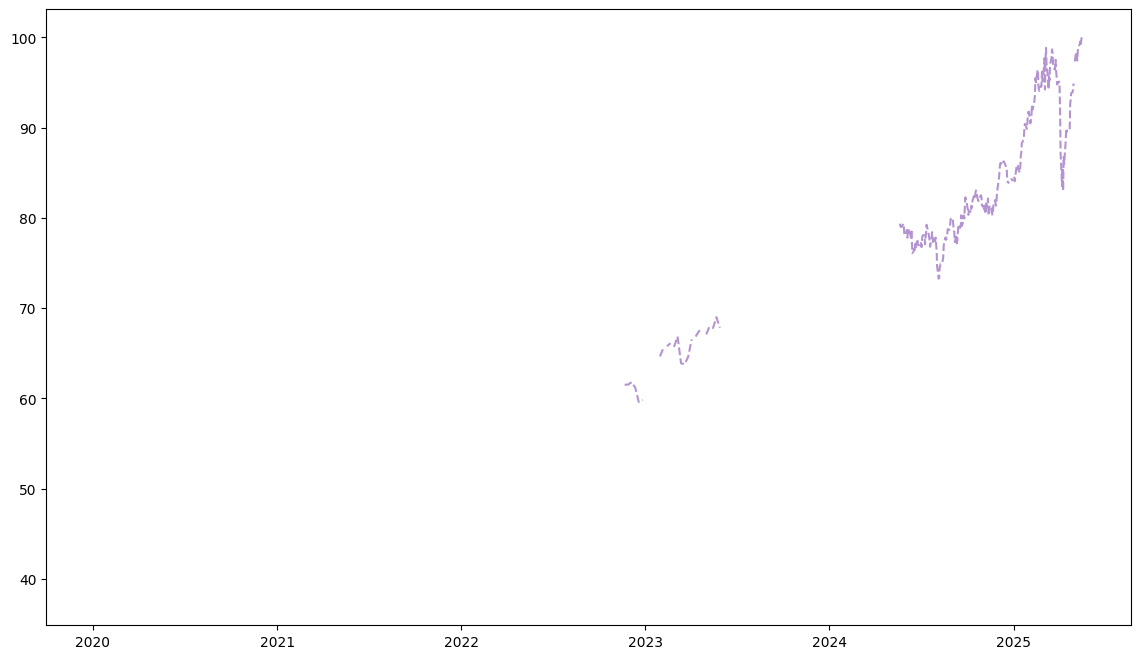

In [15]:
# Select top 5 funds by Sharpe ratio for cleaner visualization
if risk_return_3y is not None:
    top_funds = risk_return_3y.sort_values('sharpe', ascending=False).head(5).index.tolist()
else:
    top_funds = sample_funds[:5]  # Use first 5 if we don't have risk-return data
    
# Compare with benchmarks
normalized_ts, diff_from_benchmark = s.compare_with_benchmarks(
    fund_isins=top_funds,
    benchmark_isins=benchmark_isins,
    start_date='2020-01-01',  # Start from 2020
    normalize_date='2025-05-16',  # Normalize to beginning of 2020
    plot_diff=True  # Plot difference from benchmarks
)

### 3.1 Compare Against Specific Market Events

Let's see how these funds performed during specific market events, like the COVID-19 crash and recovery.

Not in ts: ['issuer', 'investment_focus', 'type', 'name', 'region']
Normalize date 2020-02-01 not found, using closest date 2020-02-02 00:00:00


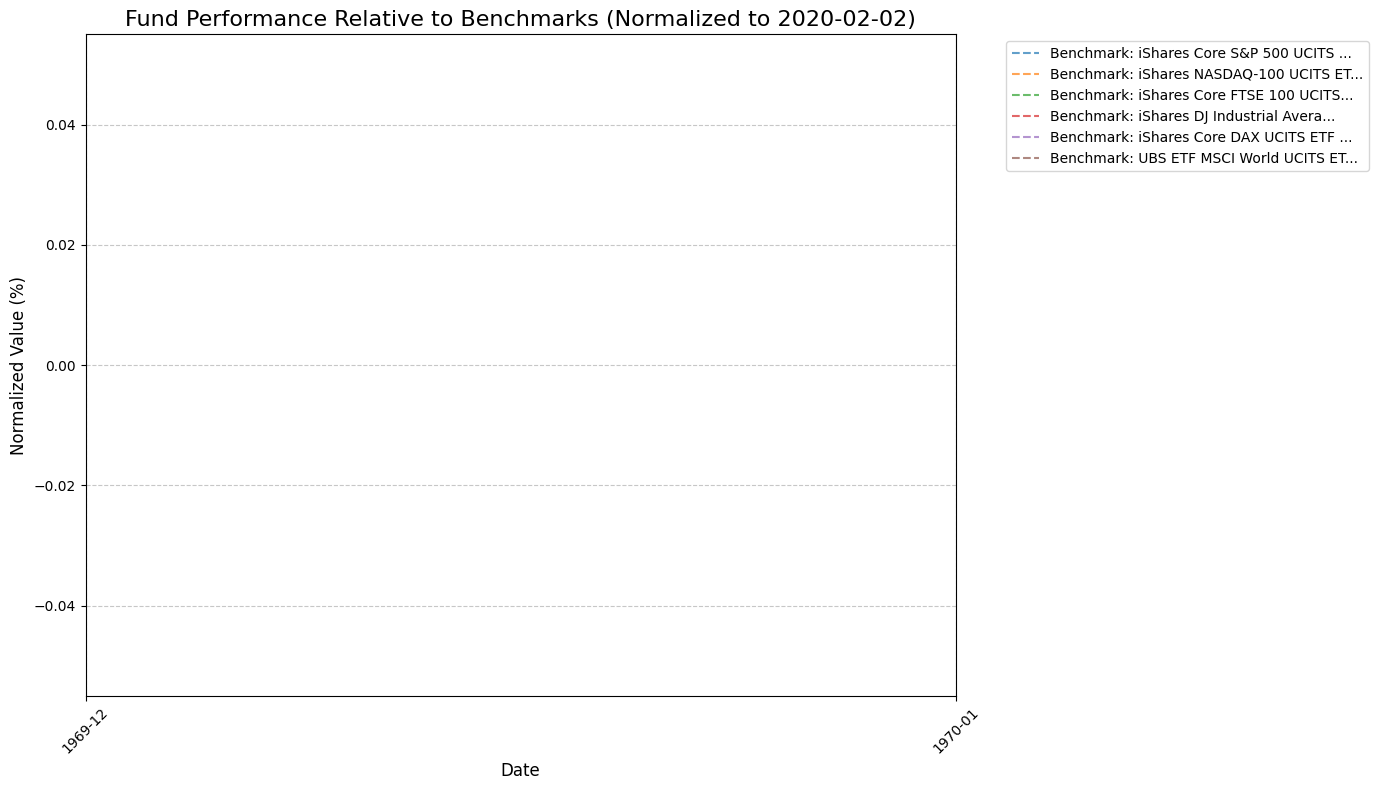

Not in ts: ['issuer', 'investment_focus', 'type', 'name', 'region']


AttributeError: 'str' object has no attribute 'strftime'

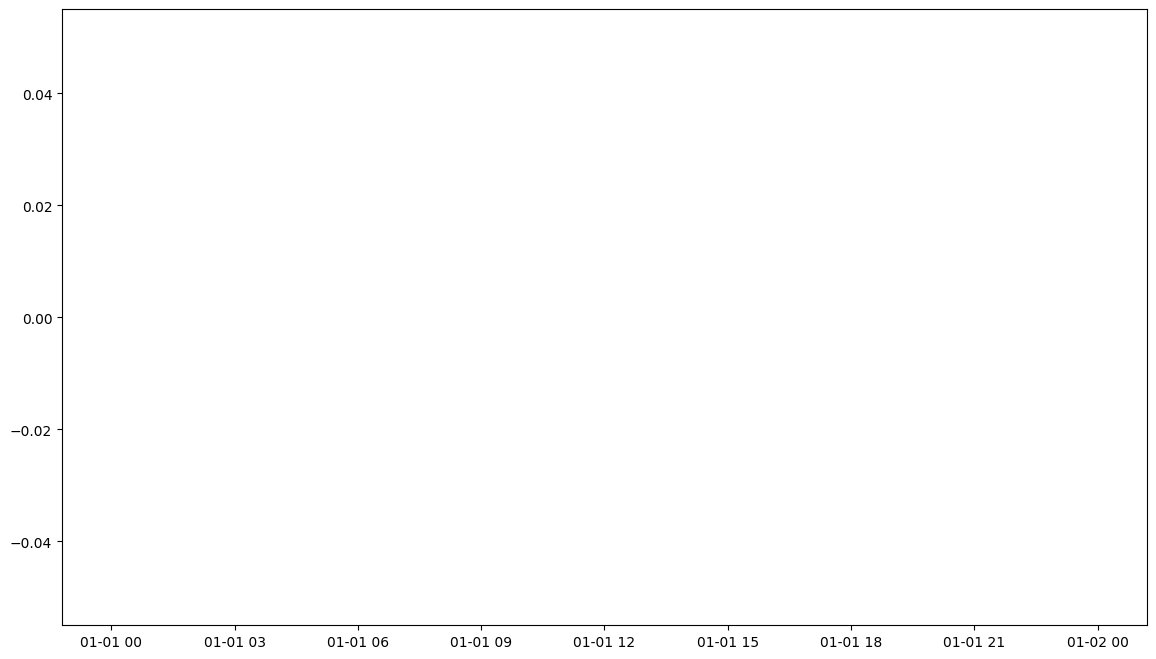

In [16]:
# COVID-19 crash period
covid_crash_ts, _ = s.compare_with_benchmarks(
    fund_isins=top_funds,
    benchmark_isins=benchmark_isins,
    start_date='2020-02-01',  
    end_date='2020-04-30',
    normalize_date='2020-02-01',
    plot_diff=False
)

# COVID-19 recovery period
covid_recovery_ts, _ = s.compare_with_benchmarks(
    fund_isins=top_funds,
    benchmark_isins=benchmark_isins,
    start_date='2020-03-23',  # Approximate market bottom
    end_date='2020-12-31',
    normalize_date='2020-03-23',
    plot_diff=False
)

## 4. Advanced Analysis: Drawdown Comparison

Let's calculate and visualize the drawdown for our funds to see how they handle downside risk.

Not in ts: ['name', 'type', 'investment_focus', 'region', 'issuer']


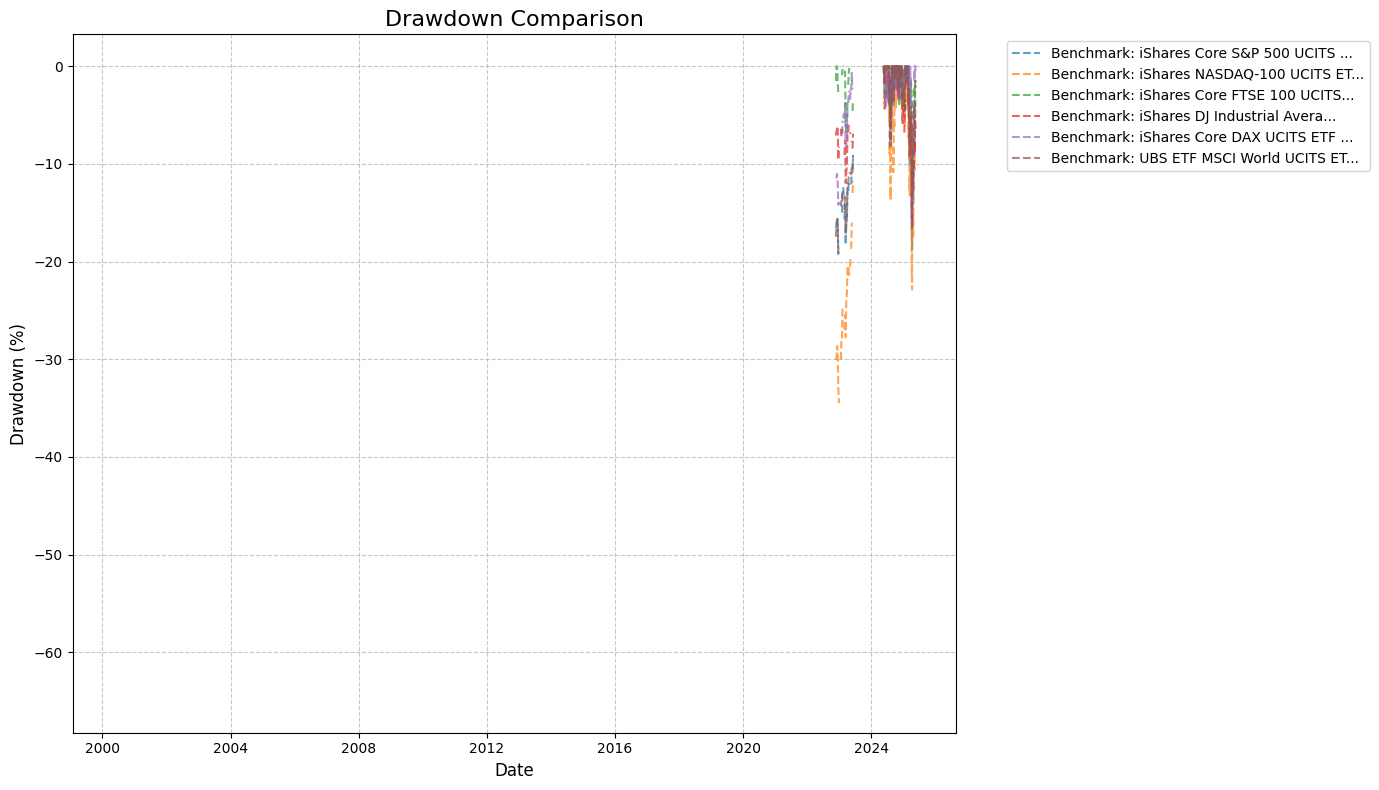

,Maximum Drawdown (%)
DE0005933931,-64.974619
DE000A0F5UF5,-50.249660
DE0006289390,-49.440053
LU0340285161,-49.180902
IE0005042456,-44.766355
IE00B5BMR087,-29.085113


In [17]:
def calculate_drawdown(ts_data):
    """Calculate drawdown for each time series in the DataFrame"""
    roll_max = ts_data.cummax()
    drawdown = (ts_data / roll_max - 1) * 100  # Convert to percentage
    return drawdown

# Get time series data for our funds
ts_data = s.select_ts(top_funds + benchmark_isins)

# Calculate drawdown
drawdown = calculate_drawdown(ts_data)

# Plot drawdown
plt.figure(figsize=(14, 8))

# Plot funds drawdown
for isin in top_funds:
    if isin in drawdown.columns:
        label = isin
        if 'name' in s.funds_overview.columns and isin in s.funds_overview.index:
            label = s.funds_overview.loc[isin, 'name']
            if isinstance(label, str) and len(label) > 30:
                label = label[:28] + '...'
        plt.plot(drawdown.index, drawdown[isin], label=label, linewidth=2)

# Plot benchmark drawdown
for isin in benchmark_isins:
    if isin in drawdown.columns:
        label = f"Benchmark: {isin}"
        if 'name' in s.funds_overview.columns and isin in s.funds_overview.index:
            label = f"Benchmark: {s.funds_overview.loc[isin, 'name']}"
            if isinstance(label, str) and len(label) > 40:
                label = label[:38] + '...'
        plt.plot(drawdown.index, drawdown[isin], label=label, linestyle='--', linewidth=1.5, alpha=0.7)

plt.title('Drawdown Comparison', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Drawdown (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print maximum drawdown for each fund
max_drawdown = drawdown.min()
max_drawdown.sort_values().to_frame('Maximum Drawdown (%)').head(len(top_funds) + len(benchmark_isins))

## 5. Conclusion and Recommendations

Based on the analyses above, we can draw several conclusions and make recommendations:

1. **Correlation Analysis**: We can identify funds that have low correlation with benchmarks, which could provide good diversification benefits.

2. **Risk-Return Profile**: Funds with the highest Sharpe ratios offer the best risk-adjusted returns and should be prioritized in a portfolio.

3. **Benchmark Comparison**: We can see which funds consistently outperform their benchmarks and which ones struggle during specific market conditions.

4. **Drawdown Analysis**: Funds with lower maximum drawdowns offer better downside protection, which is particularly important for risk-averse investors.

### Additional Benchmarking Suggestions:

1. **Sector-Specific Benchmarks**: For sustainable funds, compare against specialized ESG indices like MSCI World ESG Leaders or FTSE4Good.

2. **Style Benchmarks**: Compare growth-oriented funds against growth indices and value-oriented funds against value indices.

3. **Risk-Adjusted Performance**: Compare funds not just on raw returns but also on metrics like information ratio (outperformance per unit of tracking error).

4. **Rolling Period Analysis**: Analyze performance over rolling periods (e.g., rolling 36-month windows) to identify consistency of outperformance.

5. **Factor Analysis**: Decompose returns into exposure to common factors like market, size, value, momentum, etc., to better understand sources of returns.